# 01 — Reading raw ADCP files and plotting XYZ velocities


**Data:** Healy cruise `hly2018`, OS150 (150 kHz, downward-looking)  
**Location:** `~/adcpcode/programs/pycurrents_test_data/uhdas_data/raw/os150/`

Run from the `pycodas` environment:
```bash
conda activate pycodas
jupyter notebook
```

---
###  Questions?

What are XYZ coordinates?
I think i figure out but need to double check

Why does the gbin does not have the same amout of points?

---
# 1. Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pycurrents.adcp.raw_multi import Multiread

---
# 2. Point to the raw files



## 2.1 ADCP files

### OS150

In [6]:
raw_dir_os150 = Path.home() / 'adcpcode/programs/pycurrents_test_data/uhdas_data/raw/os150'
# Path.home() = PosixPath('/Users/alesan')

# check what's there
raw_files_1 = sorted(raw_dir_os150.glob('*.raw'))
print(f'Found {len(raw_files_1)} .raw files:')
for f in raw_files_1:
    print(' ', f.name)

Found 7 .raw files:
  hly2018_149_40762.raw
  hly2018_149_43200.raw
  hly2018_149_50400.raw
  hly2018_149_57600.raw
  hly2018_149_64800.raw
  hly2018_149_72000.raw
  hly2018_149_79200.raw



The 7 files above are from 2018, I'm assuming 149 is the day (May 29?) and the next number not sure, looks like 72000 seconds (2 hrs) data count from the day?

### OS75

In [7]:
raw_dir_os75 = Path.home() / 'adcpcode/programs/pycurrents_test_data/uhdas_data/raw/os75'
# Path.home() = PosixPath('/Users/alesan')

# check what's there
raw_files_2 = sorted(raw_dir_os75.glob('*.raw'))
print(f'Found {len(raw_files_2)} .raw files:')
for f in raw_files_2:
    print(' ', f.name)

Found 7 .raw files:
  hly2018_149_40762.raw
  hly2018_149_43200.raw
  hly2018_149_50400.raw
  hly2018_149_57600.raw
  hly2018_149_64800.raw
  hly2018_149_72000.raw
  hly2018_149_79200.raw


## 2.1 ploting map

gbin data, we check several different instruments


In [4]:
from pathlib import Path
from pycurrents.file.binfile_n import BinfileSet

gbin_dir = Path.home() / 'adcpcode/programs/pycurrents_test_data/uhdas_data/gbin/os150/posmv'

gps_files = sorted(gbin_dir.glob('*.gps.gbin'))
print(f'Found {len(gps_files)} GPS files')

gps = BinfileSet([str(f) for f in gps_files])

print('lon shape:', gps.lon.shape)
print('lat shape:', gps.lat.shape)
print('lon range:', np.nanmin(gps.lon), '–', np.nanmax(gps.lon))
print('lat range:', np.nanmin(gps.lat), '–', np.nanmax(gps.lat))
print('NaN count in lon:', np.sum(np.isnan(gps.lon)))



Found 7 GPS files
lon shape: (18028,)
lat shape: (18028,)
lon range: 233.3707401863087 – 233.8389531259793
lat range: 48.035177698276904 – 48.13961904215118
NaN count in lon: 335


All navigation files (almost all) have 18028

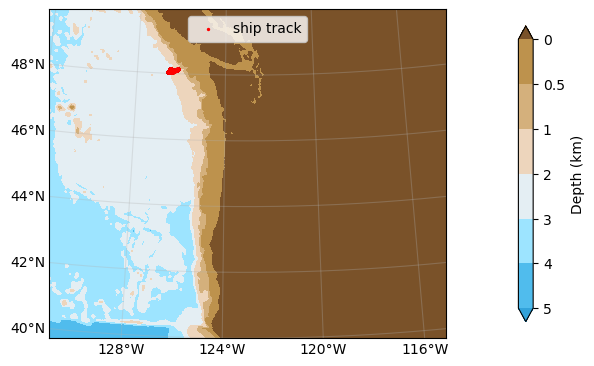

In [8]:
from pycurrents.plot.maptools import mapper

# clean up NaNs first
valid = ~np.isnan(gps.lon) & ~np.isnan(gps.lat)
map = mapper([230.0, 244.85], [40, 49.2])
map.topo()
map.grid()
x, y = map(gps.lon[valid], gps.lat[valid])   # lon/lat → map x/y
map.ax.scatter(x, y, s=2, c='red', zorder=5, label='ship track')
map.ax.legend()


---
# 3. Open raw(ish) ADCP files with Multiread

`Multiread` treats all 7 two-hour files as one continuous dataset?  

<div style="background-color:#f8d7da; color:#721c24; padding:10px; border-radius:5px;">
🔴 <b>question:</b> what happens in Multiread if the sonar does not match the file sonar downloaded?
</div>


In [10]:
m1 = Multiread(str(raw_dir_os150 / 'hly*.raw'), 'os150')
m1.conflist

[('bb', 80, 4.0, 7.0, 4.0), ('nb', 40, 8.0, 7.0, 8.0)]

In [11]:
m2 = Multiread(str(raw_dir_os75 / 'hly*.raw'), 'os75')
m2.conflist

[('bb', 80, 8.0, 8.0, 8.0), ('nb', 40, 16.0, 8.0, 16.0)]

Below: chunks is the same for both OS sonars, and for bb and nb.....

In [13]:
print(m1.bbchunks)
print(m1.nbchunks)

[array([0, 1, 2, 3, 4, 5, 6])]
[array([0, 1, 2, 3, 4, 5, 6])]



<div style="background-color:#f8d7da; color:#721c24; padding:10px; border-radius:5px;">
🔴 <b>question:</b> Not sure why above, they both state the same about of file. Is it because is interleaved? ?
</div>

In [14]:
print('ADCP configurations found:')

print(f'\nFile chunks: {m1.nbchunks}')
print(f'Sonar: {m1.sonar}')

for conf in m1.conflist:
    mode, n_bins, cell_size, blank, pulse = conf
    print(f'  mode={mode}, bins={n_bins}, cell={cell_size}m, blank={blank}m, pulse={pulse}m')


print(f'\nFile chunks: {m2.nbchunks}')
print(f'Sonar: {m2.sonar}')
for conf in m2.conflist:
    mode, n_bins, cell_size, blank, pulse = conf
    print(f'  mode={mode}, bins={n_bins}, cell={cell_size}m, blank={blank}m, pulse={pulse}m')




ADCP configurations found:

File chunks: [array([0, 1, 2, 3, 4, 5, 6])]
Sonar: os150
  mode=bb, bins=80, cell=4.0m, blank=7.0m, pulse=4.0m
  mode=nb, bins=40, cell=8.0m, blank=7.0m, pulse=8.0m

File chunks: [array([0, 1, 2, 3, 4, 5, 6])]
Sonar: os75
  mode=bb, bins=80, cell=8.0m, blank=8.0m, pulse=8.0m
  mode=nb, bins=40, cell=16.0m, blank=8.0m, pulse=16.0m


---
# 4. Ping type and read

This ADCP alternates between **broadband (bb)** and **narrowband (nb)** pings.  
Broadband — it has more depth bins (80 × 4 m = 320 m range). (less pings per bin?) -- in a very scarse-particle water this might not be the best idea

**-----Change m1 and m2 to plot different instrumesnts and bb or nb to plot different ones**

In [29]:
m1.set_pingtype('nb')

# read everything
d = m1.read()


**To see all the information that d has uncomment below**

In [26]:
# list(d.keys())

In [30]:
print(f'Sonar: {d["sonar"]}')
print(f'Pulse: ??? { d["Pulse"]}')
print(f'numb_pings ? {d["num_pings"]}')
print(f'NPings {d["NPings"]}')
print(f'Number of nprofs (Profiles?): {d["nprofs"]}')
print(f'Number of bins: {d["nbins"]}')
print(f'Velocity: {d["vel"].shape}')
print(f'XYZE:      {d["xyze"].shape}')
print(f'Depth range: {d["dep"][0]:.1f} m – {d["dep"][-1]:.1f} m')
print(f'Time range:  dday {d["dday"].min():.4f} – {d["dday"].max():.4f}')
print(f'Coordinate system: {d["trans"]["coordsystem"]}')

Sonar: os150
Pulse: ??? 8.0
numb_pings ? [1 1 1 ... 1 1 1]
NPings 1
Number of nprofs (Profiles?): 18129
Number of bins: 40
Velocity: (18129, 40, 4)
XYZE:      (18129, 40, 4)
Depth range: 15.0 m – 327.0 m
Time range:  dday 149.4718 – 149.9332
Coordinate system: beam


QUESTION:---So above, is it number of pings X bins X beams?

### Information on the Pings
*pulse* has to do with the sonar and the bb and nb ... 

### Comparison with GPS gbin data

_--? QUESTION Why is this number not the same as the ADCP pings

In [31]:
print('GPS lon shape:', gps.lon.shape)
print('GPS dday shape:', gps.dday.shape)
print('ADCP pings:', d['dday'].shape)


GPS lon shape: (18028,)
GPS dday shape: (18028,)
ADCP pings: (18129,)


In [32]:
adu_files = sorted(gbin_dir.glob('*.adu.gbin'))
adu = BinfileSet([str(f) for f in adu_files])

print([k for k in dir(adu) if not k.startswith('_')])


['allfilenames', 'array', 'cname', 'emptyfilenames', 'filenames', 'get_array', 'get_slicevardict', 'get_slicevars', 'masked', 'records', 'set_range', 'set_slice', 'slicevardict', 'slicevars']


---
# 5. Extract XYZ components


In [33]:
dday = d['dday']   # time axis — decimal day
dep  = d['dep']    # depth axis — meters

# split out the four components
vel_1 = d['vel'][:, :, 0]   
vel_2 = d['vel'][:, :, 1] #---> is this the same as vel2 (etc)
vel_3 = d['vel'][:, :, 2]   
vel_4 = d['vel'][:, :, 3]  

d_x = d['xyze'][:, :, 0]   
d_y = d['xyze'][:, :, 1] 
d_z = d['xyze'][:, :, 2]   
d_e = d['xyze'][:, :, 3]  


print('x  — mean:', np.nanmean(d_x), 'std:', np.nanstd(d_x))
print('y  — mean:', np.nanmean(d_y), 'std:', np.nanstd(d_y))
print('z  — mean:', np.nanmean(d_z), 'std:', np.nanstd(d_z))
print('e — mean:', np.nanmean(d_e), 'std:', np.nanstd(d_e))



# quick sanity check
print('vel_1  — mean:', np.nanmean(vel_1), 'std:', np.nanstd(vel_1))
print('vel_2  — mean:', np.nanmean(vel_2), 'std:', np.nanstd(vel_2))
print('vel_3  — mean:', np.nanmean(vel_3), 'std:', np.nanstd(vel_3))
print('vel_4 — mean:', np.nanmean(vel_4), 'std:', np.nanstd(vel_4))

x  — mean: 1.8158405156184756 std: 0.6361602573786208
y  — mean: -3.3148419714716675 std: 0.9698000192305269
z  — mean: -0.06380056821183837 std: 0.2819169582033033
e — mean: -0.00409181105483637 std: 0.19776835346329238
vel_1  — mean: 0.8572134879186014 std: 0.3956398892280935
vel_2  — mean: -0.9813429635742158 std: 0.4368092136921908
vel_3  — mean: 1.6179807754776034 std: 0.5325481422603232
vel_4 — mean: -1.7238536631743433 std: 0.5555419816881747


From transform.py

xyz_mat = np.array([[a, -a,  0,  0],   # x: from beams 1 & 2? 
                    [0,  0, -a,  a],   # y: from beams 3 & 4?
                    [b,  b,  b,  b],   # z: from all beams?
                    [d,  d, -d, -d]])  # error

QUESTION: how do you know what directions are the beams? 1 and 2 and 3 and 4 (pairs so x-diresiong ship? instrument?, and y -directions ship?)

---
# 6. Plot XYZ 



In [34]:
d.trans

{'coordsystem': 'beam', 'tilts': False, 'threebeam': False, 'binmap': False}

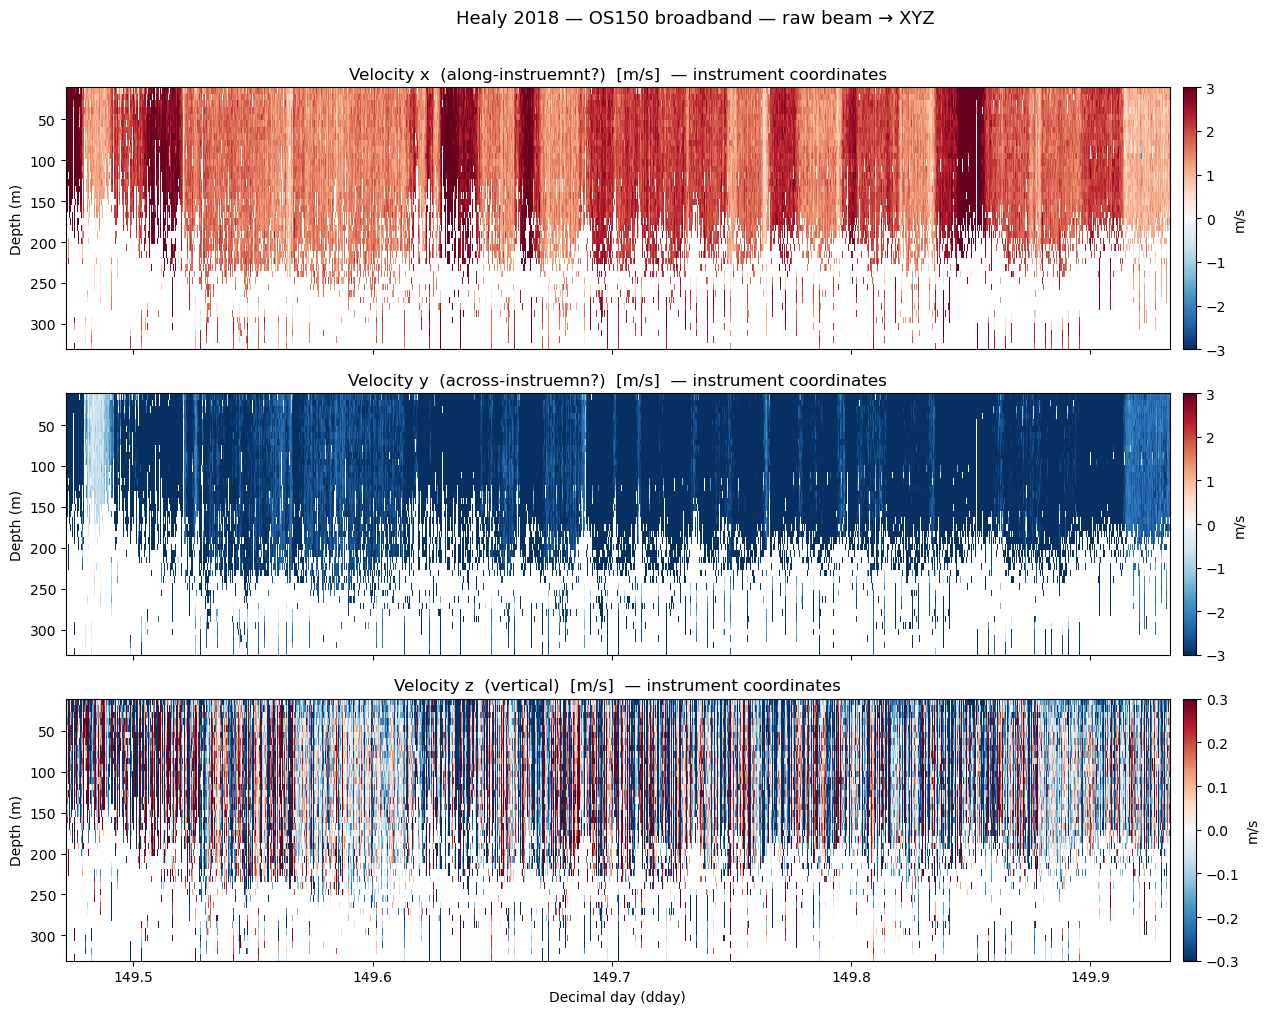

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, sharey=True)

components = [
    (d_x, 'x  (along-instruemnt?)',   'RdBu_r', 3),
    (d_y, 'y  (across-instruemn?)',  'RdBu_r', 3),
    (d_z, 'z  (vertical)',     'RdBu_r', 0.3),   # vertical is much smaller!
]

for ax, (vel, label, cmap, vlim) in zip(axes, components):
    pcm = ax.pcolormesh(
        dday,
        dep,
        vel.T,           # transpose: bins on y-axis, time on x-axis
        cmap=cmap,
        vmin=-vlim,
        vmax=vlim,
        shading='auto'
    )
    ax.invert_yaxis()    # depth increases downward
    ax.set_ylabel('Depth (m)')
    ax.set_title(f'Velocity {label}  [m/s]  — instrument coordinates')
    plt.colorbar(pcm, ax=ax, label='m/s', pad=0.01)

axes[-1].set_xlabel('Decimal day (dday)')
fig.suptitle('Healy 2018 — OS150 broadband — raw beam → XYZ', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In the couple of cells above, we can change the m1.setping('nb') or 'bb' and we can se the difference on the depth range of the pings? 

So if I understand this correctly these are plots of single pings values from a specific sonar and type ('nb', 'bb')

---
# 7. Error velocity 

The **error velocity** (`e`) 


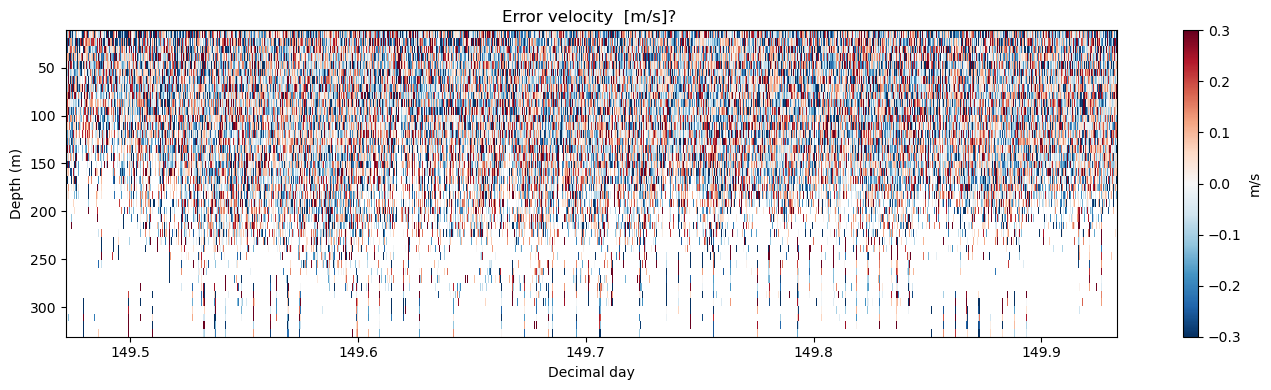

In [36]:
fig, ax = plt.subplots(figsize=(14, 4))

pcm = ax.pcolormesh(
    dday, dep, d_e.T,
    cmap='RdBu_r', vmin=-0.3, vmax=0.3,
    shading='auto'
)
ax.invert_yaxis()
ax.set_xlabel('Decimal day')
ax.set_ylabel('Depth (m)')
ax.set_title('Error velocity  [m/s]? ')
plt.colorbar(pcm, ax=ax, label='m/s')
plt.tight_layout()
plt.show()

Question? If we only have 3 beams, we can't have an error value?

---
# 8. amplitude and correlation 

`d['amp']` has shape `(pings, bins, 4 beams)`.  
`d['cor']` has same shape



In [ ]:
amp_mean = d['amp'].mean(axis=2)   # average over 4 beams → shape (pings, bins)

fig, ax = plt.subplots(figsize=(14, 4))

pcm = ax.pcolormesh(
    dday, dep, amp_mean.T,
    cmap='viridis',
    shading='auto'
)
ax.invert_yaxis()
ax.set_xlabel('Decimal day')
ax.set_ylabel('Depth (m)')
ax.set_title(' amplitude (beam average)')
plt.colorbar(pcm, ax=ax, label='counts (0–255)')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True, sharey=True)

for beam_idx, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        dday, dep, d['amp'][:, :, beam_idx].T,
        cmap='viridis', vmin=0, vmax=255,
        shading='auto'
    )
    
    ax.set_ylabel('Depth (m)')
    ax.set_title(f' amplitude — Beam {beam_idx + 1}')
    plt.colorbar(pcm, ax=ax, label='counts (0–255)')
    

axes[0].set_ylim(dep[-1], dep[0])   # dep[-1] = deepest, dep[0] = shallowest
axes[-1].set_xlabel('Decimal day')
plt.tight_layout()
plt.show()


In [ ]:
cor_mean = d['cor'].mean(axis=2)   # (In matlab it would be axis 3!!!! --- aaahhhhg 

fig, ax = plt.subplots(figsize=(14, 4))

pcm = ax.pcolormesh(
    dday, dep, cor_mean.T, # transpose
    cmap='viridis',
    shading='auto'
)
ax.invert_yaxis()
ax.set_xlabel('Decimal day')
ax.set_ylabel('Depth (m)')
ax.set_title('Correlation (beam average)')
plt.colorbar(pcm, ax=ax, label='counts (0–255)')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True, sharey=True)

for beam_idx, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        dday, dep, d['cor'][:, :, beam_idx].T,
        cmap='viridis', vmin=0, vmax=255,
        shading='auto'
    )
    
    ax.set_ylabel('Depth (m)')
    ax.set_title(f' Correlation — Beam {beam_idx + 1}')
    plt.colorbar(pcm, ax=ax, label='counts (0–255)')
    

axes[0].set_ylim(dep[-1], dep[0])   # dep[-1] = deepest, dep[0] = shallowest
axes[-1].set_xlabel('Decimal day')
plt.tight_layout()
plt.show()


---
# 9. Transducer misalignment angle

how many degrees off the ADCP is mounted relative to the ship centerline

Below is a test where I chack different BINS (depths) the function is using to estimate this misaligment. This will later go to another part of the post-processing

In [39]:
from pycurrents.adcp import EA_estimator

# use bin index 2 (0-based), ship speed cutoff 2 m/s
result = EA_estimator.make_pretty(d, underway=2, bin=2)
print(result)

for b in [1, 2, 4, 8]:
    result = EA_estimator.make_pretty(d, underway=2, bin=b)
    print(f'bin {b}:', result)




# mean   stddev  N
28.16    5.72  16934
no bottom track data found
bin 1: 
# mean   stddev  N
28.18    5.52  16761
no bottom track data found
bin 2: 
# mean   stddev  N
28.16    5.72  16934
no bottom track data found
bin 4: 
# mean   stddev  N
28.23    5.55  17043
no bottom track data found
bin 8: 
# mean   stddev  N
28.22    5.47  16947
no bottom track data found


---
# Apendix:  What's in `d` — full key reference

```python
list(d.keys())
```

| key | shape | description |
|---|---|---|
| `dday` | (pings,) | decimal day timestamp |
| `dep` | (bins,) | depth of each bin (m) |
| `vel` | (pings, bins, 4) | beam velocities (m/s) — raw |
| `xyze` | (pings, bins, 4) | instrument XYZ+error (m/s) |
| `amp` | (pings, bins, 4) | echo amplitude per beam (0–255) |
| `cor` | (pings, bins, 4) | beam correlation (0–255) — quality |
| `bt_vel` | (pings, 4) | bottom-track velocity (masked in deep water) |
| `bt_depth` | (pings, 4) | bottom-track depth (masked in deep water) |
| `temperature` | (pings,) | transducer temperature (°C) |
| `heading` | (pings,) | ship heading (°) |
| `pitch` | (pings,) | ship pitch (°) |
| `roll` | (pings,) | ship roll (°) |
| `FL` | dict | fixed leader: hardware config |
| `VL` | recarray | variable leader: per-ping header |
| `times` | recarray | UHDAS timing: u_dday, m_dday, offsets |
| `sysconfig` | dict | `{'angle':30, 'kHz':150, 'convex':True, 'up':False}` |
| `trans` | dict | coordinate transform info |

